# Gradient Descent

In [12]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

## 1. Define $f(\theta)$ and its gradient $\nabla f(\theta)$

$$f(x,y) = (x-3)^2 + (y+1)^2$$

which has a known minimum at $(x,y) = (3,-1)$. Its gradient is:

$$\nabla f(x,y) = \big[\, 2(x-3),\ 2(y+1) \,\big]$$

In [13]:
def f(x, y):
    return (x - 3)**2 + (y + 1)**2

def grad_f(x, y):
    return np.array([2 * (x - 3), 2 * (y + 1)])

## 2. Implement the gradient descent loop

Each step moves opposite the gradient, scaled by a learning rate $\lambda$:

$$\theta_{n+1} = \theta_n - \lambda \, \nabla f(\theta_n)$$

In [14]:
def gradient_descent(start, lr, n_steps, grad_fn=grad_f):
    ''' Run gradient descent for n_steps. return the full path taken
    '''
    xy = np.array(start)
    path = [xy.copy()]
    for _ in range(n_steps):
        xy = xy - lr * grad_fn(*xy)
        path.append(xy.copy())
    return np.array(path)

## 3. Run it from (0, 0)

Try a learning rate first $\lambda = 0.1$ and see where we land.

In [15]:
path = gradient_descent(start=(0, 0), lr=0.1, n_steps=50)
print(f"Final theta: {path[-1]}")
print(f"f at final theta: {f(*path[-1]):.6f}")

Final theta: [ 2.99995718 -0.99998573]
f at final theta: 0.000000


## 4. Visualize the path on a contour plot

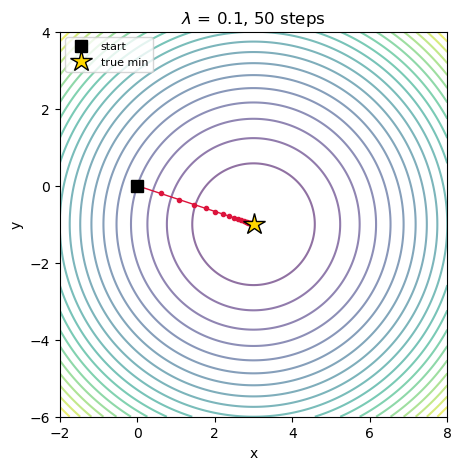

In [16]:
def plot_path(path, lr, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    xg = np.linspace(-2, 8, 200)
    yg = np.linspace(-6, 4, 200)
    X, Y = np.meshgrid(xg, yg)
    Z = f(X, Y)

    ax.contour(X, Y, Z, levels=20, cmap="viridis", alpha=0.6)
    ax.plot(path[:, 0], path[:, 1], "o-", color="crimson", markersize=3, linewidth=1)
    ax.plot(*path[0], "s", color="black", markersize=8, label="start")
    ax.plot(3, -1, "*", color="gold", markersize=16, markeredgecolor="black", label="true min")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"$\\lambda$ = {lr}, {len(path)-1} steps")
    ax.legend(loc="upper left", fontsize=8)
    return ax

plot_path(path, lr=0.1)
plt.show()

## 5. Compare learning rates

Try $\lambda$ = 0.01, 0.1, 0.5, 1.1 — same starting point, same number of steps.

lambda=0.01  final theta=[ 1.90749096 -0.63583032],  f=1.326
lambda=0.1   final theta=[ 2.99995718 -0.99998573],  f=2.037e-09
lambda=0.5   final theta=[ 3. -1.],  f=0
lambda=1.1   final theta=[-27298.31445001   9099.43815   ],  f=8.282e+08


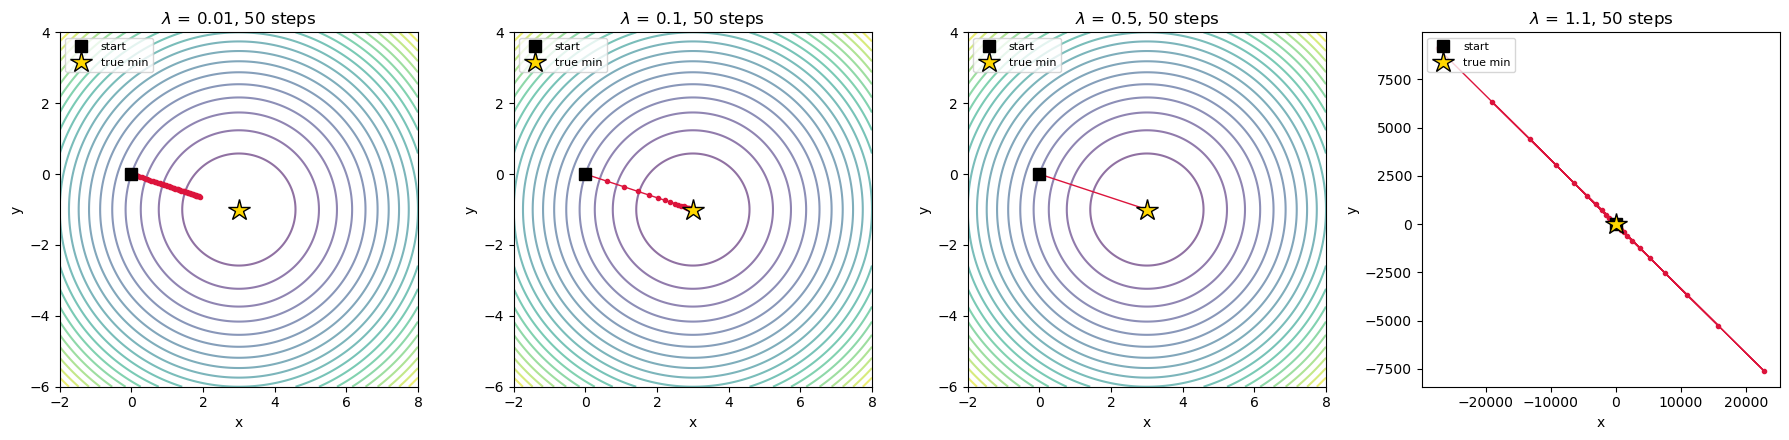

In [17]:
learning_rates = [0.01, 0.1, 0.5, 1.1]
n_steps = 50

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for lr, ax in zip(learning_rates, axes):
    path = gradient_descent(start=(0, 0), lr=lr, n_steps=n_steps)
    plot_path(path, lr, ax=ax)
    print(f"lambda={lr:<5} final theta={path[-1]},  f={f(*path[-1]):.4g}")

plt.tight_layout()
plt.show()